## Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Looking at the dataset

In [3]:
data = pd.read_csv(r'final_data.csv')
data.head()

,TransactionID,CustomerID,PurchaseDate,Product,Category,Quantity,UnitPrice,City,Gender,Age,...,UnitPrice_Norm,Age_Norm,Clusters,Age_Bin,Age_Group,Total_Spend,Purchase_Year,Purchase_Month,Season,Cluster_Label_Desc
0,1,CUST2620,24-04-2024,Dress,Women'S Wear,2,1442.0,Mumbai,Female,65,...,0.288515,0.726027,2,Old People,60+,2884.0,2024,4,Summer,Budget Buyers
1,1,CUST2620,24-04-2024,Handbag,Accessories,2,3978.0,Bangalore,Male,55,...,0.795918,0.589041,1,Seniors,45-59,7956.0,2024,4,Summer,Premium Buyers
2,2,CUST1409,10-09-2025,Jeans,Bottomwear,1,4821.0,Bangalore,Male,36,...,0.964586,0.328767,1,Seniors,30-44,4821.0,2025,9,Autumn,Premium Buyers
3,2,CUST1409,10-09-2025,Belt,Accessories,3,4013.0,Bangalore,Female,58,...,0.802921,0.630137,1,Seniors,45-59,12039.0,2025,9,Autumn,Premium Buyers
4,2,CUST1409,10-09-2025,Shorts,Bottomwear,3,4861.0,Mumbai,Male,32,...,0.972589,0.273973,1,Adults,30-44,14583.0,2025,9,Autumn,Premium Buyers


# Problem Statement
### Retail businesses often struggle to understand customer purchasing behaviour and identify hidden relationships among products. Without analyzing transaction data, businesses cannot effectively segment customers, recommend products, or implement cross-selling strategies. Therefore, this project aims to analyze customer purchase transactions to understand purchasing behaviour, discover frequently purchased product combinations, identify customer segments, and generate actionable business recommendations.

# Sales Performance Analysis

### Which month and year generated the highest sales revenue?

<Figure size 1200x600 with 0 Axes>

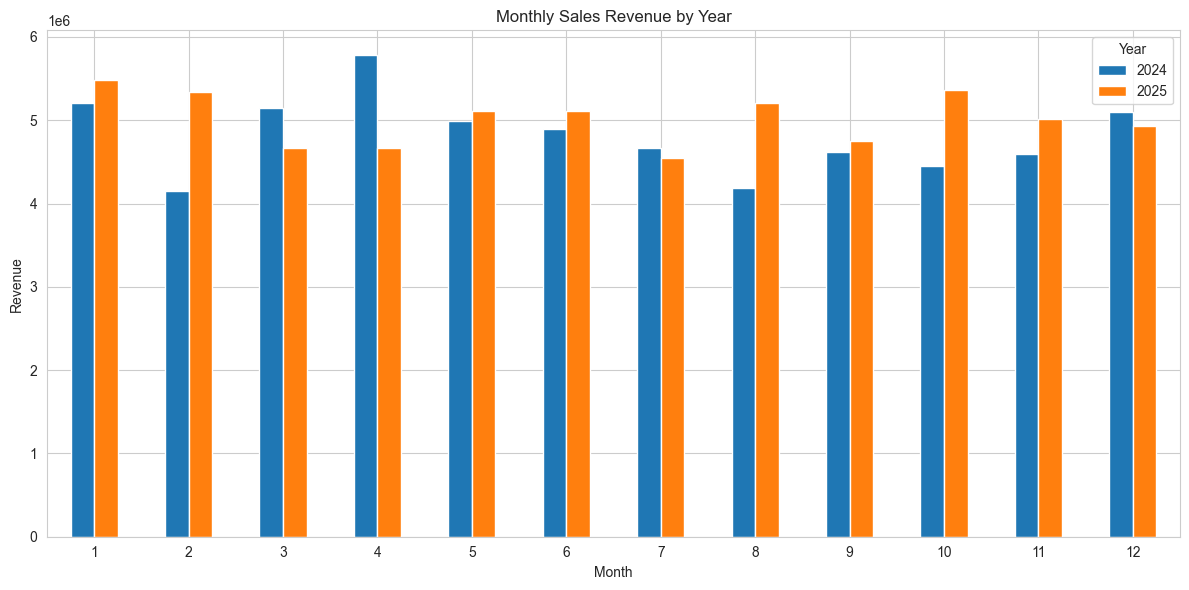

In [39]:
sales_month_year = (
    data.groupby(['Purchase_Year','Purchase_Month'])['Total_Spend']
    .sum()
    .reset_index()
)

pivot_sales = sales_month_year.pivot(
    index='Purchase_Month',
    columns='Purchase_Year',
    values='Total_Spend'
)

plt.figure(figsize=(12,6))

pivot_sales.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Monthly Sales Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.tight_layout()

plt.show()

### Which season contributes the highest sales revenue?

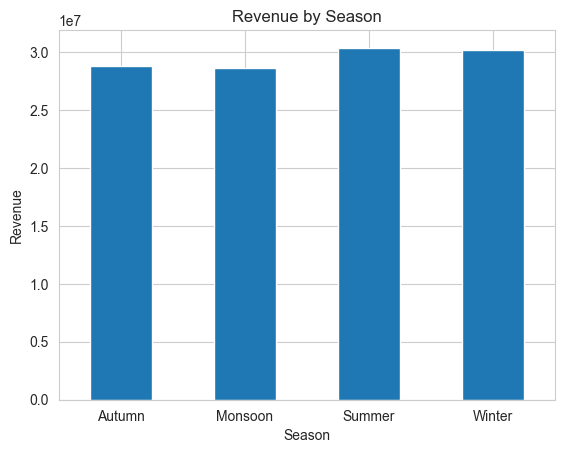

In [7]:
season_sales = data.groupby('Season')['Total_Spend'].sum()

season_sales.plot(kind='bar')
plt.title('Revenue by Season')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

### How has sales performance changed across different years?

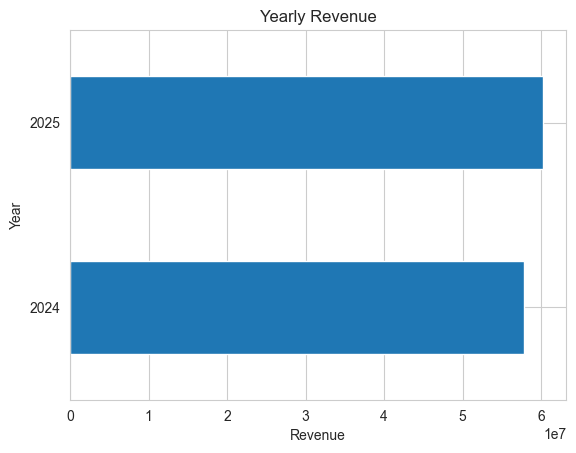

In [40]:
year_sales = data.groupby('Purchase_Year')['Total_Spend'].sum()

year_sales.plot(kind='barh')
plt.title('Yearly Revenue')
plt.ylabel('Year')
plt.xlabel('Revenue')
plt.show()

# Product Analysis

### Which products are purchased most frequently by customers?

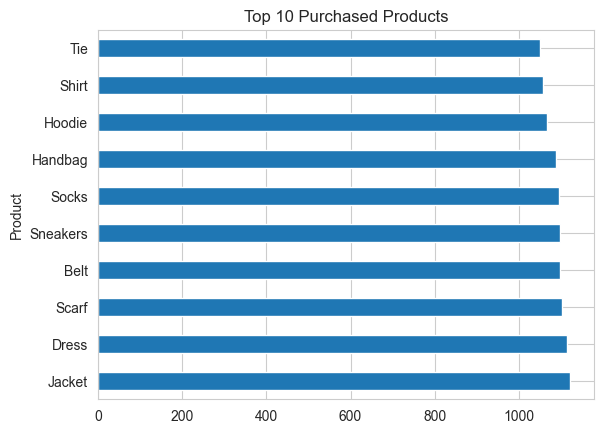

In [43]:
top_products = data['Product'].value_counts().head(10)

top_products.plot(kind='barh')
plt.title('Top 10 Purchased Products')
plt.show()

### Which product categories generate the highest sales?

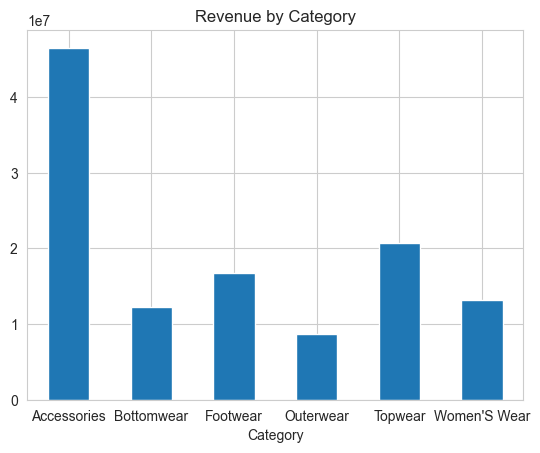

In [12]:
category_sales = data.groupby('Category')['Total_Spend'].sum()

category_sales.plot(kind='bar')
plt.title('Revenue by Category')
plt.xticks(rotation=0)
plt.show()

### Which products generate the highest revenue?

<Axes: ylabel='Product'>

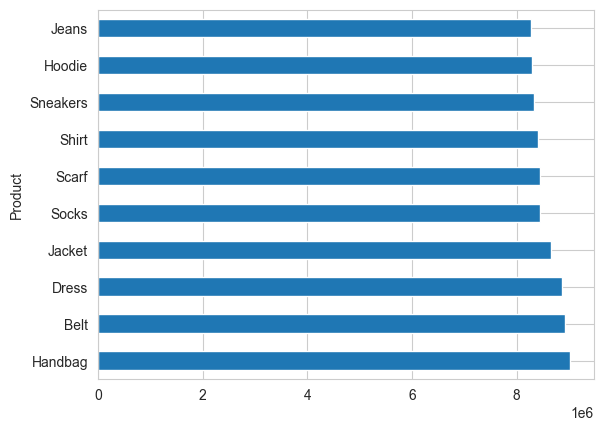

In [13]:
product_revenue = data.groupby('Product')['Total_Spend'].sum()

product_revenue.sort_values(
    ascending=False
).head(10).plot(kind='barh')

# Customer Demographic Analysis

### Which age group contributes the highest sales?

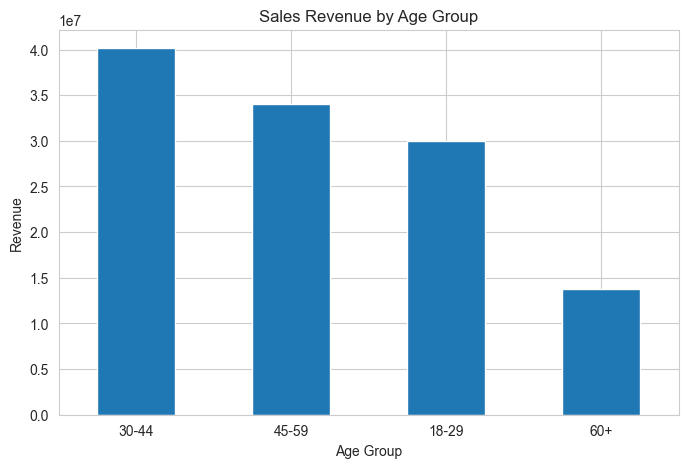

In [31]:
age_sales = data.groupby('Age_Group')['Total_Spend'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
age_sales.plot(kind='bar')

plt.title('Sales Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.show()

### What is the age distribution of customers purchasing different product categories?

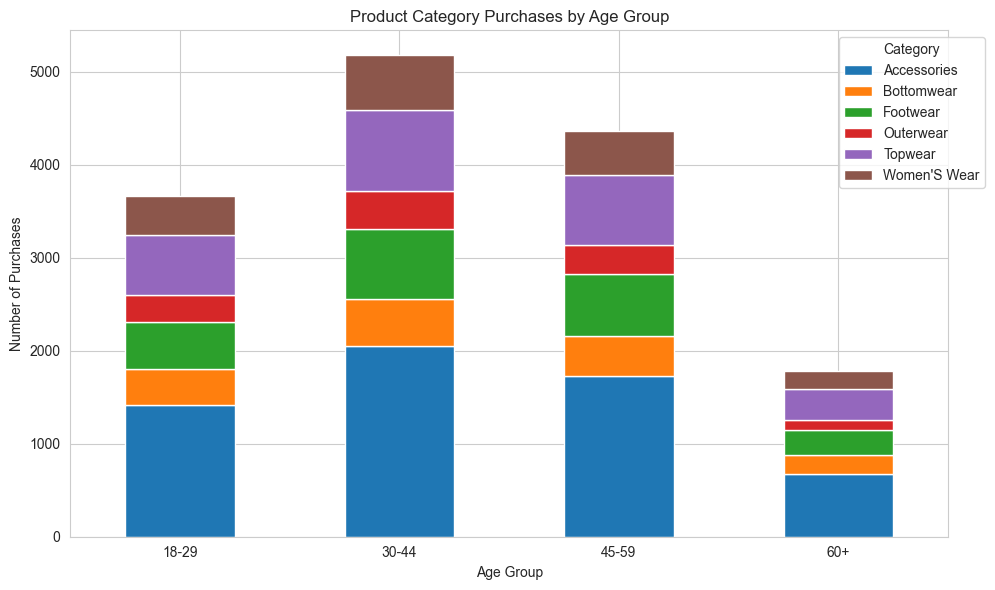

In [44]:
age_category = pd.crosstab(
    data['Age_Group'],
    data['Category']
)

age_category.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Product Category Purchases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

### Which gender contributes the highest revenue?

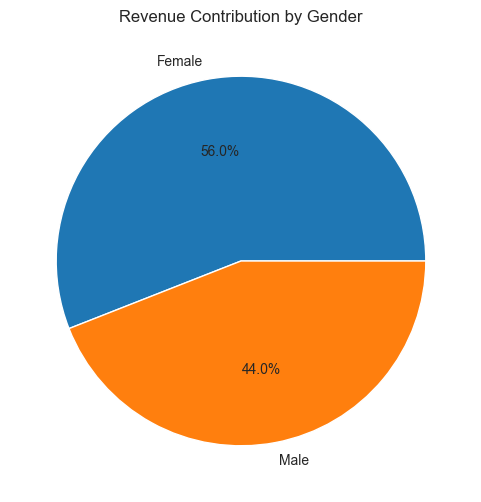

In [45]:
gender_sales = data.groupby('Gender')['Total_Spend'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    gender_sales,
    labels=gender_sales.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution by Gender')

plt.show()

### Which cities generate the highest sales revenue?

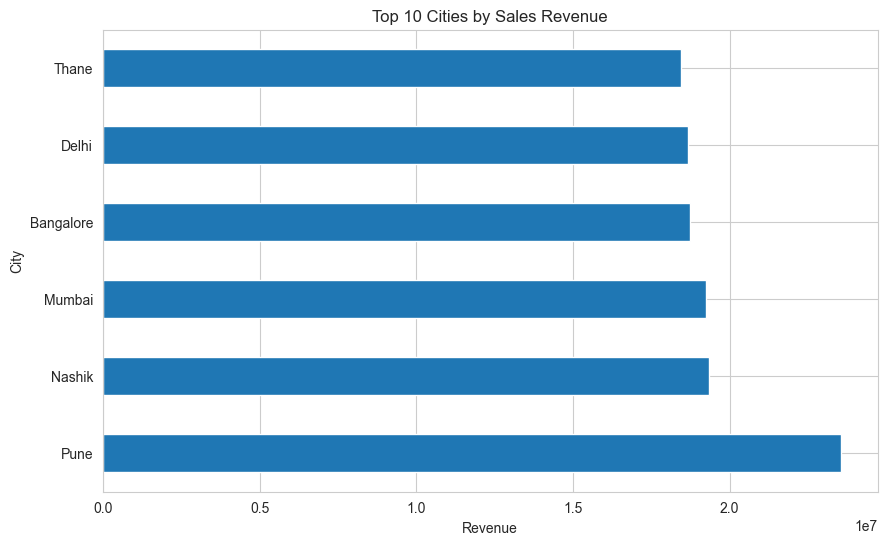

In [34]:
city_sales = (
    data.groupby('City')['Total_Spend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

city_sales.plot(kind='barh')

plt.title('Top 10 Cities by Sales Revenue')
plt.xlabel('Revenue')
plt.ylabel('City')

plt.show()

# Customer Purchase Behaviour Analysis

### How many products are typically purchased in a single transaction?

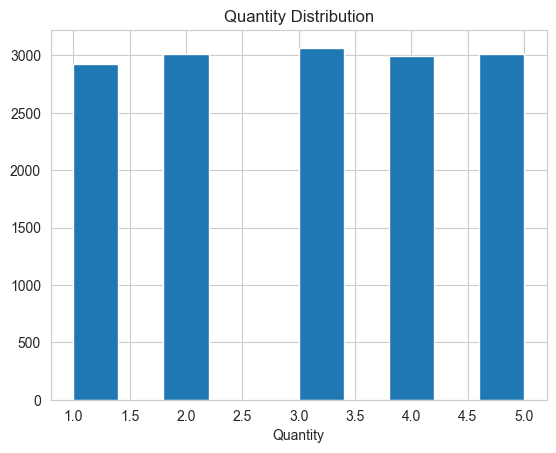

In [46]:
plt.hist(
    data['Quantity'],
    bins=10
)

plt.title(
    'Quantity Distribution'
)
plt.xlabel('Quantity')
plt.show()

### How many customers are repeat buyers?

([<matplotlib.patches.Wedge at 0x1f92a97aad0>,
 [Text(-1.099966797331382, 0.008546623224557829, 'Repeat'),
  Text(1.0999667960408652, -0.008546789314923274, 'One-Time')],
 [Text(-0.5999818894534811, 0.004661794486122451, '99.8%'),
  Text(0.5999818887495628, -0.00466188508086724, '0.2%')])

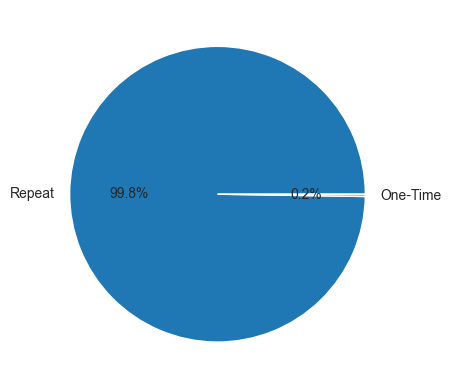

In [25]:
repeat = data.groupby(
    'CustomerID'
)['TransactionID'].count()

counts = [
    (repeat>1).sum(),
    (repeat==1).sum()
]

plt.pie(
    counts,
    labels=[
        'Repeat',
        'One-Time'
    ],
    autopct='%1.1f%%'
)

### Which customers contribute the highest revenue?

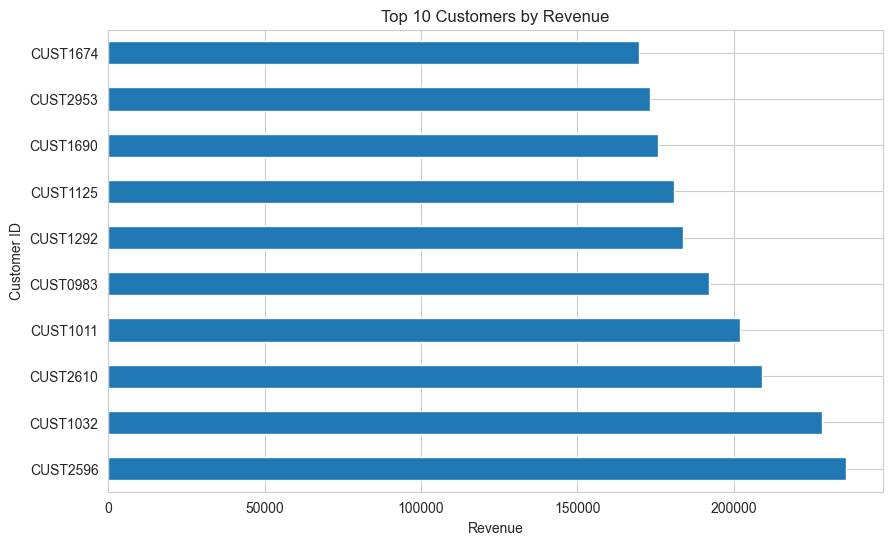

In [35]:
top_customers = (
    data.groupby('CustomerID')['Total_Spend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_customers.plot(kind='barh')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')

plt.show()

# Customer Segmentation Analysis

### How are customers distributed across the identified clusters?

(array([0, 1, 2]),
 [Text(0, 0, 'Frequent Buyers'),
  Text(1, 0, 'Budget Buyers'),
  Text(2, 0, 'Premium Buyers')])

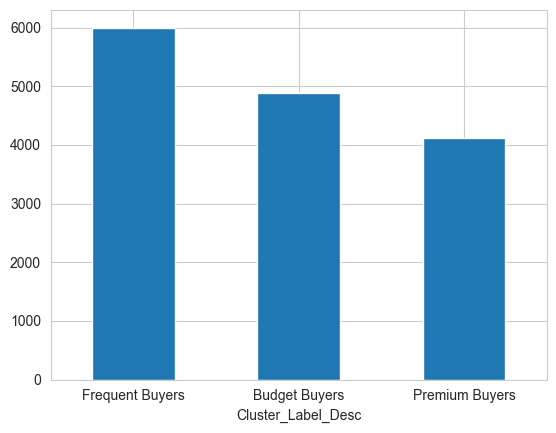

In [27]:
data[
    'Cluster_Label_Desc'
].value_counts().plot(
    kind='bar'
)
plt.xticks(rotation=0)

### Which customer segment generates the highest revenue?

(array([0, 1, 2]),
 [Text(0, 0, 'Budget Buyers'),
  Text(1, 0, 'Frequent Buyers'),
  Text(2, 0, 'Premium Buyers')])

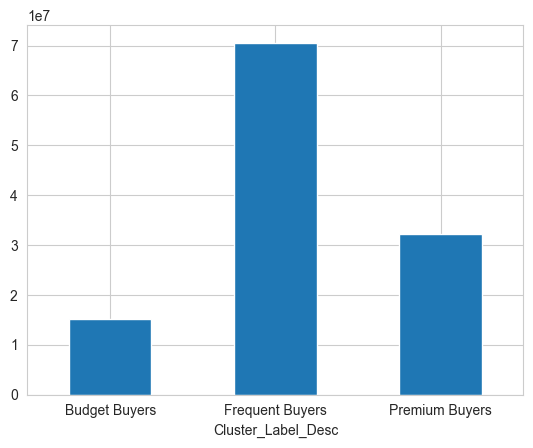

In [29]:
cluster_sales = data.groupby(
    'Cluster_Label_Desc'
)['Total_Spend'].sum()

cluster_sales.plot(kind='bar')
plt.xticks(rotation=0)

### Which customer segment purchases the highest quantity of products?

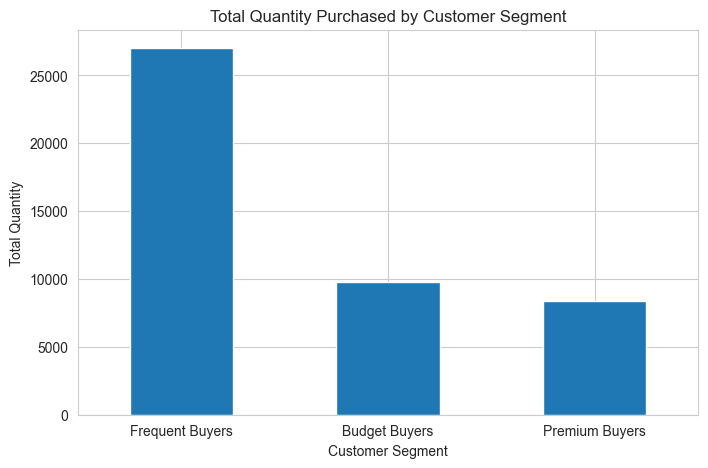

In [36]:
cluster_quantity = (
    data.groupby('Cluster_Label_Desc')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

cluster_quantity.plot(kind='bar')

plt.title('Total Quantity Purchased by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Quantity')

plt.xticks(rotation=0)

plt.show()

### How does purchasing behaviour differ among Frequent Buyers, Premium Buyers, and Budget Buyers?

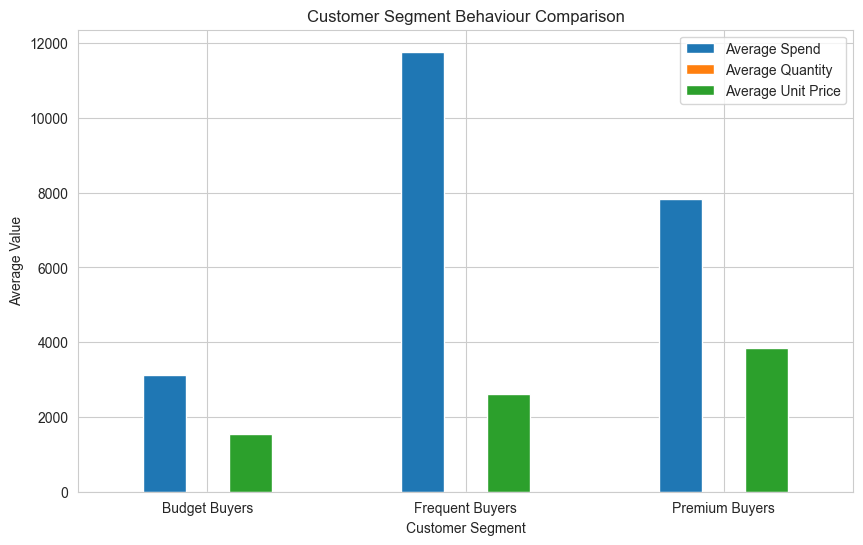

In [37]:
cluster_behavior = data.groupby('Cluster_Label_Desc').agg({
    'Total_Spend':'mean',
    'Quantity':'mean',
    'UnitPrice':'mean'
})

cluster_behavior.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Customer Segment Behaviour Comparison')
plt.xlabel('Customer Segment')
plt.ylabel('Average Value')

plt.xticks(rotation=0)

plt.legend([
    'Average Spend',
    'Average Quantity',
    'Average Unit Price'
])

plt.show()

# Market Basket Analysis

### Which products are most frequently purchased together?

* Cap and Hoodie
* Jeans and Belt
* Jacket and Scarf
* Shirt and Tie
* Sneakers and Socks
* Dress and Handbag

### Which product combinations have the strongest association?

* Cap ↔ Hoodie (Lift 3.30)
* Jeans ↔ Belt (Lift 3.16)
* Jacket ↔ Scarf (Lift 3.15)
* Shirt ↔ Tie (Lift 3.13)
* Sneakers ↔ Socks (Lift 3.12)

### Which products should be bundled together to increase sales?

* Hoodie + Cap
* Jeans + Belt
* Jacket + Scarf
* Shirt + Tie
* Sneakers + Socks
* Dress + Handbag

### What cross-selling opportunities can be identified from customer transactions?

Recommend:
* Belt when Jeans are purchased.
* Socks when Sneakers are purchased.
* Handbag when Dress is purchased.
* Cap when Hoodie is purchased.

### How can association rules be used to improve product recommendations?

Association rules can be integrated into recommendation systems to suggest complementary products during checkout, increasing average order value and improving customer experience.

# Business Recommendations

### Which products should be promoted together?

* Hoodie and Cap
* Jeans and Belt
* Sneakers and Socks
* Jacket and Scarf
* Dress and Handbag

### Which customer segment should be targeted for premium product campaigns?

* Premium Buyers (Cluster 1)
* Reason:
* Highest average unit price (~₹3841)
* Willing to spend more per purchase

### Which customer segment is most suitable for loyalty programs?

* Frequent Buyers (Cluster 0)
* Reason:
* Largest segment
* Highest average quantity purchased (4.5 products)

### Which customer segment is most responsive to discounts and promotional offers?

* Budget Buyers (Cluster 2)
* Reason:
* Lowest average spending
* More price-sensitive purchasing behaviour

### What business strategies can be implemented to increase average transaction value?

* Bundle frequently purchased products.
* Cross-sell complementary items.
* Offer premium product recommendations to Premium Buyers.
* Introduce loyalty rewards for Frequent Buyers.
* Create discount bundles for Budget Buyers.
* Use personalized product recommendations based on purchasing behaviour.